# Module 2. Stars, Planets, & The Galaxy

In <a href="./MODULE0.ipynb"> <code>MODULE0.ipynb</code></a>, you proved that the variance in a star's lightcurve was due to both its <b>proper motion</b> and an exoplanet transiting it. In <a href="./MODULE1.ipynb"><code>MODULE1.ipynb</code></a>, you discovered how noise can mask the periodic signals of exoplanets and how algorithms like Fourier transforms and the Box-Least-Squared method can be used to unmask these signals. Now, let's explore exoplanets in the Galactic frame. In this module, we'll investigate how stars and their galactic environment influence the type of exoplanets formed. 

### Learning goals: 
- Use the APOGEE allStar catalog to explore how stars bias our observations of exoplanet transits and influence planet formation.
- Identify trends in the locations, metallicities, radial velocities, radii, and orbital distances of stars and planets in the Milky Way. 
- Relate these trends to planet formation.

Again, we'll install our dependencies:

In [1]:
import setup as s
from setup import * 

Installing dependencies...
Processing /home/conda/feedstock_root/build_artifacts/appnope_1733332318622/work (from -r requirements.txt (line 1))


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/System/Volumes/Data/home/conda/feedstock_root/build_artifacts/appnope_1733332318622/work'



Done!
Could not import regions, which is required for some of the functionalities of this module.
APOGEE allStar found!


## Module 2.1: Meeting the host

To start, we need a larger population of objects than what we've been working with. Let's read in the massive APOGEE allStar catalog.

In [2]:
# read in APOGEE, this will take a minute 
apogee_allstar = s.fitsio.read('allStar-dr17-synspec_rev1.fits', ext = 1)
# ignore all APOGEE stars that lack RA and/or DEC values 
m = np.isnan(apogee_allstar['RA']) | np.isnan(apogee_allstar['DEC'])
apogee_allstar = apogee_allstar[~m]

We'll also read in our table of exoplanets. You can use the table obtained in Module 1, but you may get better results if you "cheat" and use the <code>transiting_exoplanets.csv</code> file that contains thousands of exoplanets.

In [9]:
#exoplanets=ascii.read('exoplanet_tbl.csv')
exoplanets=ascii.read('transiting_exoplanets.csv')

Let's locate our exoplanets in APOGEE:

In [10]:
# search for an apogee match 
apogee_coords = SkyCoord(ra = apogee_allstar['RA']*u.degree, dec = apogee_allstar['DEC']*u.degree, frame = 'icrs')
planet_coords = SkyCoord(ra=exoplanets['ra']*u.degree, dec = exoplanets['dec']*u.degree, frame = 'icrs')
idx, d2d, d3d = planet_coords.match_to_catalog_sky(apogee_coords) # idx is the index of the closest apogee source for each exoplanet, d2d is the on-sky separation between the exoplanet and its closest apogee source, and d3d is the 3D separation (which we won't use here)
m_t_idx = d2d.arcsec < 1 # we'll want to exclude objects that fall further than 1'' from an apogee source 
exoplanets['apogee idx'] = idx
exoplanets_apogee_tbl = exoplanets[m_t_idx]

In [20]:
# if you wish to save computation time, limit your apogee catalog 
apogee_limit = 50000
index_list = [np.random.randint(0, len(apogee_allstar)) for i in range(apogee_limit)]
apogee_limited = apogee_allstar[index_list]

To learn about the host stars of our exoplanets, we'll plot them on a Hertzsprung Russel (HR) diagram. 
<figure>
  <img src="helpful_figures/HRDiagram.png" style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
  <div align="center">
  <figcaption>An example HR digram from the Hipparcos catalog and Gliese catalog of nearby stars by <a href="https://en.wikipedia.org/wiki/Hertzsprung%E2%80%93Russell_diagram#/media/File:HRDiagram.png" > Richard Powell </a> 
  </figcaption>
  </div>
</figure>

But first, we need to account for how being farther away affects a star's brightness. We can do this using the "distance modulus" $\mu$, which is equal to the apparent magnitude (e.g., the magnitude we see without correcting for distance) minus the absolute magnitude (the distance corrected magnitude). $\mu$ is ALSO equal to $5\log_{10}(d) -5$, a definition that comes from the conventional magnitude scale. We can solve for $M$: 
$$\mu = m - M = 5\log_{10}(d)-5$$
$$M = m - 5\log_{10}(d)-5 $$

Write the following function to find the absolute magntiude given the apparent magnitude and distance: 

In [21]:
def apparent_to_absolute(m,d): 
    M = m - 5 *np.log10(d)-5 
    return M

Now, let's select <em>only</em> nearby stars so that we don't have to worry about how the dust in the interstellar medium influences our observations. An object that is farther away will also be more heavily influenced by dust. So, by selecting only objects particularly close to us $d < 5$, we can get a pretty good approximation of the HR diagram. If we were doing anything more than an approximation of very local stars, we wouldn't be able to ignore dust like this. But, luckily, TESS targets tend to be local, so its a fair approximation to only look at our solar neighborhood.

We obtain distance from parallax: $$d=\frac{1}{p}$$
Here, distance is given in parasecs and parallax is given in arcseconds.

In [25]:
d = 1/(apogee_limited['GAIAEDR3_PARALLAX']) 

# select only local objects and objects that actually have distance values 
mask= (d < 5) & (~np.isnan(d))
d = d[mask]

In [26]:
# retrieve the magnitudes in the B, R, and G bands 
Bv = apparent_to_absolute(apogee_limited['GAIAEDR3_PHOT_BP_MEAN_MAG'][mask], d) # apply distance mask
Rv = apparent_to_absolute(apogee_limited['GAIAEDR3_PHOT_RP_MEAN_MAG'][mask],d)
Gv = apparent_to_absolute(apogee_limited['GAIAEDR3_PHOT_G_MEAN_MAG'][mask],d)

# get the color by subtracting B and R 
color = Bv-Rv 

The APOGEE catalog also contains <code>TEFF</code>, which is the effective temperature of each star. We can overplot that quantity as a color since we know stellar temperature varies as stars evolve. 

In [29]:
temp = apogee_limited['TEFF'][mask]

In [ ]:
# repeat this process for our exoplanet's host star
d_target = 1/(apogee_allstar['GAIAEDR3_PARALLAX'][exoplanets_apogee_tbl['apogee idx']]) 
Bv_target = apparent_to_absolute(apogee_allstar['GAIAEDR3_PHOT_BP_MEAN_MAG'][exoplanets_apogee_tbl['apogee idx']], d_target)
Rv_target = apparent_to_absolute(apogee_allstar['GAIAEDR3_PHOT_RP_MEAN_MAG'][exoplanets_apogee_tbl['apogee idx']],d_target)
Gv_target = apparent_to_absolute(apogee_allstar['GAIAEDR3_PHOT_G_MEAN_MAG'][exoplanets_apogee_tbl['apogee idx']],d_target)
color_target = Bv_target-Rv_target 

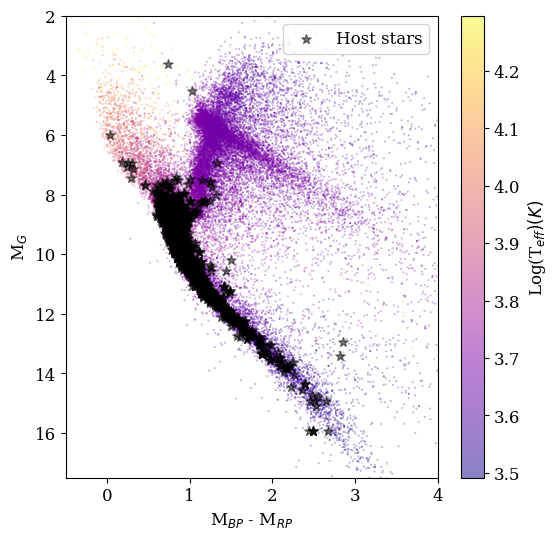

In [39]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
img = ax.scatter(color, Gv, c = np.log10(temp), cmap = 'plasma', s= 0.1, alpha = 0.5)
ax.scatter(color_target, Gv_target, color = 'k', s=50, marker = '*', label = "Host stars", zorder =5, alpha = 0.5)
ax.invert_yaxis() 
ax.set_xlabel(r"M$_{BP}$ - M$_{RP}$")
ax.set_ylabel(r"M$_{G}$")
ax.set_xlim(-0.5,4)
ax.set_ylim(17.5,2)
plt.colorbar(img, label = r"Log(T$_{eff}) (K)$")
plt.legend(loc="upper right")

Note that most of the host stars tend to occupy the main sequence! <b>Why?</b>

<b>Answer:</b> 

<b> Think about where the sun would fall on this plot. Does this make sense? Why or why not? If not, what's wrong with the plot? </b>


<b> Answer:</b>

Now, let's relate a star's position on the main sequence to some known quantities of exoplanets. 

If you look at the <code>transiting_exoplanets.csv</code> file, you'll see a few key quantities. Namely, <code>pl_orbper</code>, <code>pl_trandep</code>, and <code>pl_trandur</code>.

These are three of the quantities we calculated at the end of Section 2!

In module 0., we saw that $$ R_{planet} = \sqrt{\frac{D R_{star}^2}{1+D}}$$ and $$ t= \frac{\pi R_{orb}}{TR_{star}}$$ where $D$ is the transit depth, $t$ is the transit duration, and $T$ is the orbital period. 

<b> Complete the following functions to compute the orbital radius and planetary radius of your population of exoplanets.

In [40]:
def compute_orbitalradius(t, P, Rstar): 
    r = (2*t*P*Rstar)/(2*np.pi)
    return r 
def compute_plradius(D, Rstar): 
    R = Rstar*np.sqrt(D/(1+D))
    return R

We can use these functions:

In [42]:
rm = exoplanets_apogee_tbl['st_rad'] != 0 # removing objects that have unknown stellar radii
exoplanets_apogee_tbl = exoplanets_apogee_tbl[rm]
pl_orbrad = compute_orbitalradius(exoplanets_apogee_tbl['pl_trandur'], exoplanets_apogee_tbl['pl_orbper'], exoplanets_apogee_tbl['st_rad'])
pl_rad = compute_plradius(exoplanets_apogee_tbl['pl_trandep'], exoplanets_apogee_tbl['st_rad'])

Let's make a plot!

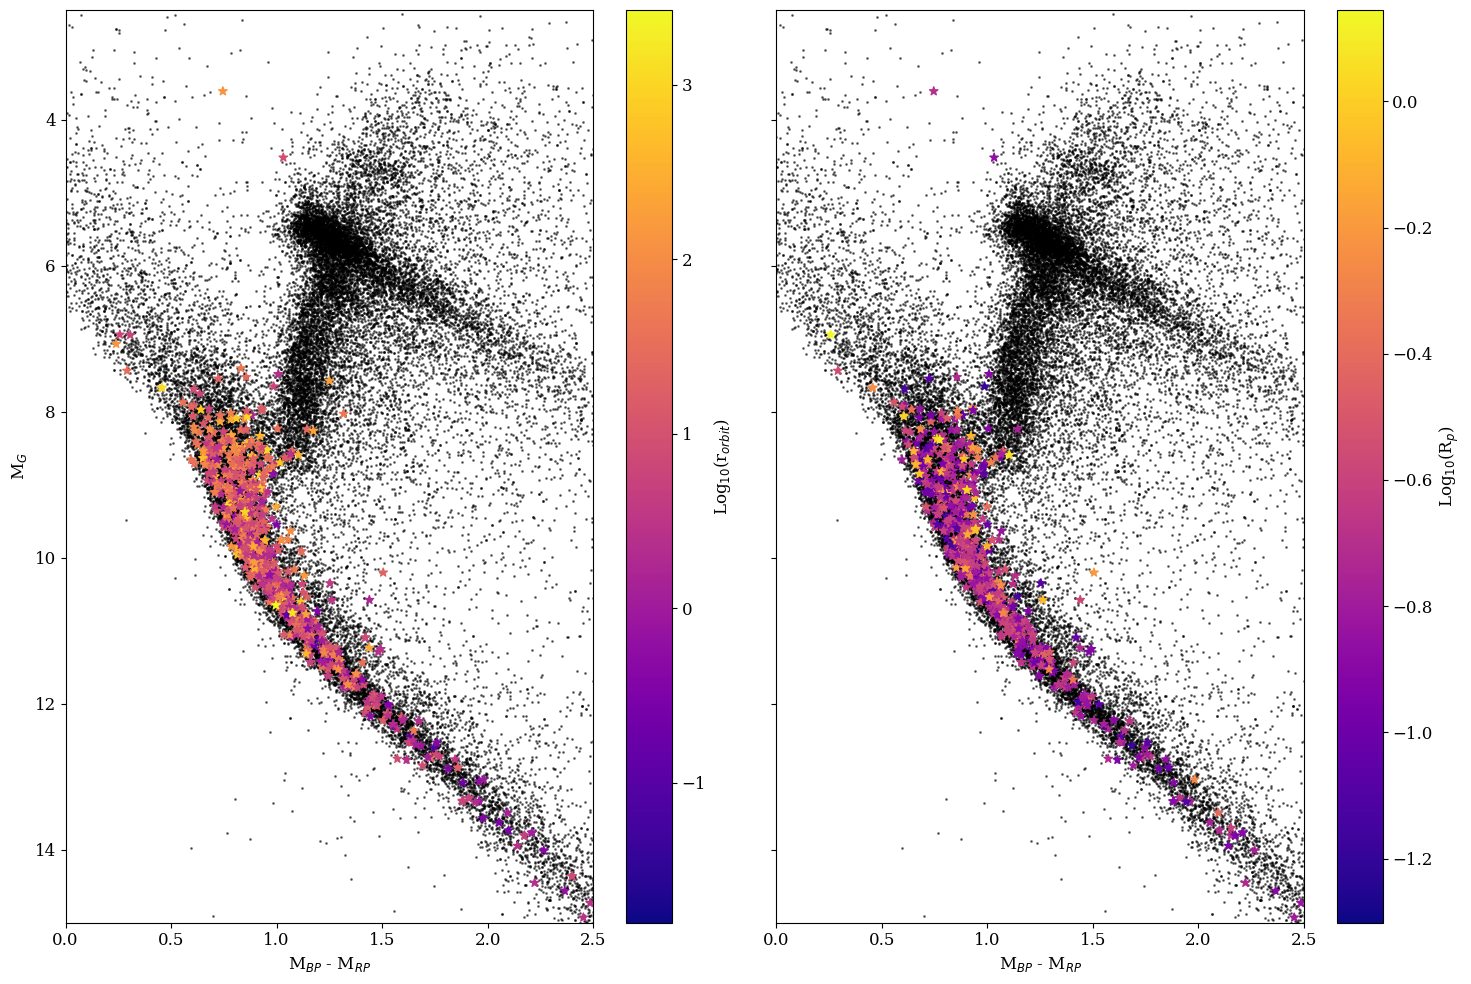

In [43]:
fig, ax = plt.subplots(1,2,figsize = (15,10), sharey=True)
ax[0].scatter(color, Gv, color = 'k', s= 1, alpha = 0.5)
ax[1].scatter(color, Gv, color = 'k', s= 1, alpha = 0.5)
img1 = ax[0].scatter(color_target[rm], Gv_target[rm], c = np.log10(pl_orbrad),  cmap = 'plasma', s=40, marker = '*')
img2= ax[1].scatter(color_target[rm], Gv_target[rm], c = np.log10(pl_rad), cmap = 'plasma', s=40, marker = '*')
ax[0].set_ylim(15, 2.5)
ax[0].set_xlim(0, 2.5)
ax[1].set_xlim(0, 2.5)
ax[0].set_xlabel(r"M$_{BP}$ - M$_{RP}$")
ax[1].set_xlabel(r"M$_{BP}$ - M$_{RP}$")
ax[0].set_ylabel(r"M$_{G}$")
plt.colorbar(img1, label = r"Log$_{10}$(r$_{orbit}$)", ax = ax[0])
plt.colorbar(img2, label = r"Log$_{10}$(R$_{p}$)", ax=ax[1])
plt.tight_layout()

Notice how planets tend to exhibit larger orbital radii for brighter stars. This is likely a result of the fact that younger stars tend to be brighter, younger, and more variable. This means that a planet around a young star: 1) Has had less time to form and 2) Will not survive if it is too close. Additionally, note the small scattering of points that fall closest to the red giant branch--they all exhibit larger orbital radii. Again, this is likely because stars expand as they begin their evolution into red giants, meaning that planets too close to their host star will be enveloped. 

Similarly, we see that planets with larger radii tend to occur more around brighter stars (if you don't see it, look for the smattering of yellow points on the right figure). However, unlike the orbital radius case, this is a selection effect! Larger planets are easier to detect and its more difficult to detect exoplanets, in general, around brighter stars. Therefore, we are more likely to see a bias toward planets with larger radii around younger stars. 

## Module 2.2: The big picture

Now that we've seen how stellar hosts influence their exoplanets, let's explore the role of the greater galactic environment. We can understand our galaxy through the following image: 
<figure>
  <img src="helpful_figures/galactic_anatomy.webp" style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
  <div align="center">
  <p>The anatomy of the Milky Way, courtesy of Kaley Brauer, MIT.</a> 
  </p>
  </div>
</figure>

Currently, many Galactic astronomers are puzzling over the Milky Way's formation. Many speculate that the thin disk was formed more recently as a result of recent gas accretion processes while the thick disk formed earlier, during a rapid and turbulent phase. We expect stars that formed in the early universe (e.g., the thick) to be less metal rich because they would have formed before Type Ia supernovae could enrich the Universe with iron and other metals. Therefore, we expect the thin disk to be metal rich and the thick disk to be metal poor. Since the exoplanets we're looking at fall in our solar neigborhood (< 5 pc), let's explore the distribution of stellar metallicities in this region. Ideally, we should see a lot of higher-metallicity stars as we fall in the thin disk of the galaxy.

In [44]:
# first, we'll select our solar neighborhood (d < 5 pc)
p = apogee_limited['GAIAEDR3_PARALLAX']
d = 1/p
m = (d < 5) & (~np.isnan(p)) & (p> 0)
neighbor_distance = d[m]
neighbors = apogee_limited[m]

Metallicity can be defined as the ratio of iron to hydrogen ([Fe/H]). However, we don't just want to know if a star is metal rich, we want to know if it contains more metal than it <em> should </em>. So, we'll need to also look at the ratio of an alpha process element (Magnesium, for example) over iron. By investigating the ratio of [Fe/H] to [Mg/Fe], we will be able to quantify if the star is more metal rich than we would otherwise expect based on its [Mg/Fe] ratio. 

Based on the image above, we should expect our local neighborhood to exhibit a higher [Fe/H] ratio than objects that fall outside the thin disk. Let's look at the differences between our solar neighborhood and the surrounding sample. We'll also look at the height ($z$) of the surrounding sample to determine whether the objects fall outside the thick disk (high $z$) or reside in the thin disk, but their radial deviation from our sun is just large. 

In [45]:
# let's find some objects that fulfill this criteria 
m = np.abs(d) > 5 

not_neighbors = apogee_limited[m]
not_neighbors_distance = d[m]

# convert to galactic coordinates 
coords = SkyCoord(ra = not_neighbors['RA']*u.degree, dec = not_neighbors['DEC']*u.degree, frame = 'icrs')
l = (coords.galactic).l
b = (coords.galactic).b

# retrieve z 
z = not_neighbors_distance*np.sin(l) 


Text(0, 0.5, '[Mg/Fe]')

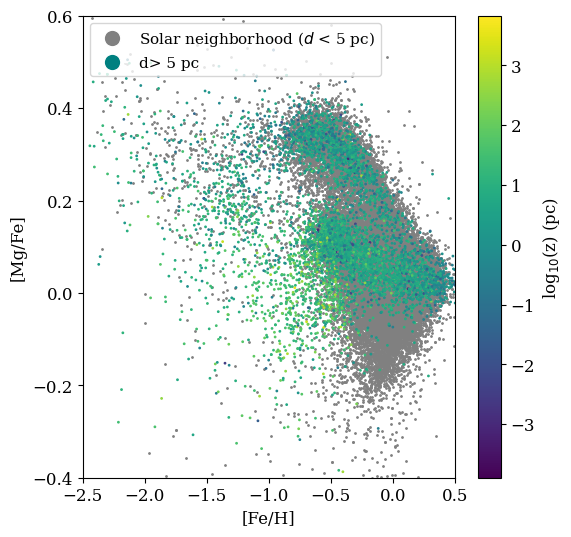

In [46]:
# make a plot! 

from matplotlib.lines import Line2D

fig, ax = plt.subplots(1,1,figsize = (6,6))
ax.scatter(neighbors['FE_H'], neighbors['MG_FE'], s= 1, label = r'Solar neighborhood ($d$ < 5 pc)', color = 'grey')
img = ax.scatter(not_neighbors['FE_H'], not_neighbors['MG_FE'], s=1, c = np.log10(z), cmap = 'viridis', label = r'$|z|$ > 5 pc')
plt.colorbar(img, label = 'log$_{10}$(z) (pc)')
ax.set_ylim(-0.4,0.6)
ax.set_xlim(-2.5,0.5)
legend_elements = [Line2D([0], [0], marker='o', color='w', label=r'Solar neighborhood ($d$ < 5 pc)',
                          markerfacecolor='grey', markersize=12), 
                          Line2D([0], [0], marker='o', color='w', label=r'd> 5 pc',
                          markerfacecolor='teal', markersize=12)]
plt.legend(handles =legend_elements, loc = 'upper left', fontsize = 11)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')

We can see that there is a group of objects that appear to fall $z \sim 100$ pc away--these objects are likely outside the Galactic halo. However, we can also see a group of objects that fall outside of the solar neighborhood but at lower scale heights. 

Fortunately, we can use the cut off defined in <a href = "https://academic.oup.com/mnras/article/489/1/176/5552689"> Mackereth et al. (2019)</a> to differentiate these ex-situ (green-ish) objects from the in-situ objects that reside in the Galactic plane. 

Text(0, 0.5, '[Mg/Fe]')

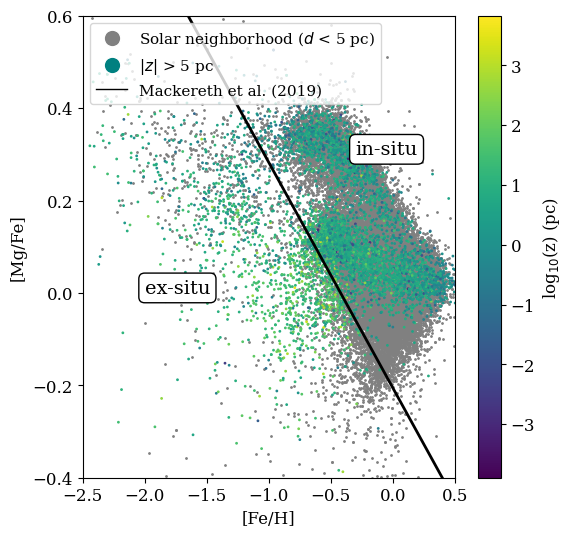

In [47]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
ax.scatter(neighbors['FE_H'], neighbors['MG_FE'], s= 1, label = r'Solar neighborhood ($d$ < 5 pc)', color = 'grey')
img = ax.scatter(not_neighbors['FE_H'], not_neighbors['MG_FE'], s=1, c = np.log10(z), cmap = 'viridis', label = r'$|z|$ > 5 pc')
plt.colorbar(img, label = 'log$_{10}$(z) (pc)')
ax.set_ylim(-0.4,0.6)
ax.set_xlim(-2.5,0.5)
ax.plot([-1.65, 0.4], [0.6, -0.4], color = 'k', linewidth = 2)
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
ax.text(-2, 0, "ex-situ",fontsize =14, bbox=props)
ax.text(-0.3, 0.3, "in-situ",fontsize =14, bbox=props)
legend_elements = [Line2D([0], [0], marker='o', color='w', label=r'Solar neighborhood ($d$ < 5 pc)',
                          markerfacecolor='grey', markersize=12), 
                          Line2D([0], [0], marker='o', color='w', label=r'$|z|$ > 5 pc',
                          markerfacecolor='teal', markersize=12), 
                          Line2D([0],[0], color = 'k', label = "Mackereth et al. (2019)")]
plt.legend(handles =legend_elements, loc = 'upper left', fontsize = 11)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')

We can see that the Galactic disk is much more metal rich than the ex-situ population. However, we still have quite a spread of metallicities across the disc. Let's use another cut off, this time from <a href="https://arxiv.org/pdf/2603.19230"> Akaba et al. (2026)</a> to differentiate between the thick and thin disks we discussed earlier. 

Text(0, 0.5, '[Mg/Fe]')

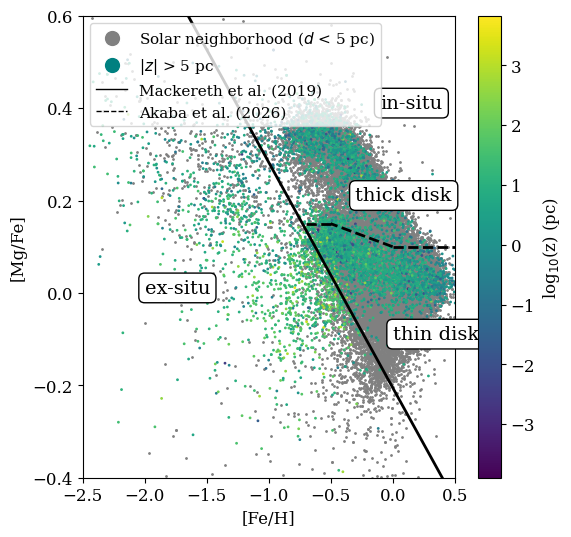

In [48]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
ax.scatter(neighbors['FE_H'], neighbors['MG_FE'], s= 1, label = r'Solar neighborhood ($d$ < 5 pc)', color = 'grey')
img = ax.scatter(not_neighbors['FE_H'], not_neighbors['MG_FE'], s=1, c = np.log10(z), cmap = 'viridis', label = r'$|z|$ > 5 pc')
plt.colorbar(img, label = 'log$_{10}$(z) (pc)')
ax.set_ylim(-0.4,0.6)
ax.set_xlim(-2.5,0.5)
ax.plot([-1.65, 0.4], [0.6, -0.4], color = 'k', linewidth = 2)
ax.plot([0,0.5],[0.1,0.1], color ='k', linewidth =2, linestyle='--')
ax.plot([0,-0.5],[0.1,0.15], color ='k', linewidth =2, linestyle='--')
ax.plot([-0.5, -0.7],[0.15,0.15], color ='k', linewidth =2, linestyle='--')
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
ax.text(-2, 0, "ex-situ",fontsize =14, bbox=props)
ax.text(-0.1, 0.4, "in-situ",fontsize =14, bbox=props)
ax.text(-0.3, 0.2, "thick disk",fontsize =14, bbox=props)
ax.text(-0.,-0.1, "thin disk",fontsize =14, bbox=props)
legend_elements = [Line2D([0], [0], marker='o', color='w', label=r'Solar neighborhood ($d$ < 5 pc)',
                          markerfacecolor='grey', markersize=12), 
                          Line2D([0], [0], marker='o', color='w', label=r'$|z|$ > 5 pc',
                          markerfacecolor='teal', markersize=12), 
                          Line2D([0],[0], color = 'k', label = "Mackereth et al. (2019)"), 
                          Line2D([0], [0], linestyle = '--', color = 'k', label = "Akaba et al. (2026)")]
plt.legend(handles =legend_elements, loc = 'upper left', fontsize = 11)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')

This tells us that the teal population that resides outside of our solar neighborhood still primarily falls in the thick disk (where the majority of our solar neighbors fall!). But why do some of our solar neighbors look like thick disk objects? 

Our answer? Galaxies are dynamic! A certain level of mixing between the thick and thin disks is to be expected. To track this mixing, we can look at the <b> radial velocities</b> of these objects. Objects with higher radial velocities are more likely to be migrating between the disks (or in/out of the halo entirely). 

Text(0, 0.5, '[Mg/Fe]')

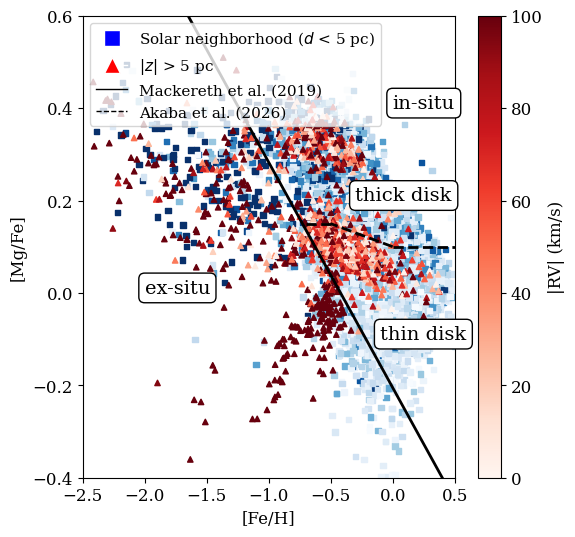

In [59]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
ax.scatter(neighbors['FE_H'], neighbors['MG_FE'], s= 15, c= np.abs(neighbors['GAIAEDR3_DR2_RADIAL_VELOCITY']), cmap = 'Blues', label = r'Solar neighborhood ($d$ < 5 pc)', marker = 's', vmin = 0, vmax=100)
img = ax.scatter(not_neighbors['FE_H'], not_neighbors['MG_FE'], s=15, c = np.abs(not_neighbors['GAIAEDR3_DR2_RADIAL_VELOCITY']), cmap = 'Reds', marker = '^', label = r'$|z|$ > 5 pc', vmin = 0, vmax=100)
plt.colorbar(img, label = '|RV| (km/s)', cmap = 'Greys')
ax.set_ylim(-0.4,0.6)
ax.set_xlim(-2.5,0.5)
ax.plot([-1.65, 0.4], [0.6, -0.4], color = 'k', linewidth = 2)
ax.plot([0,0.5],[0.1,0.1], color ='k', linewidth =2, linestyle='--')
ax.plot([0,-0.5],[0.1,0.15], color ='k', linewidth =2, linestyle='--')
ax.plot([-0.5, -0.7],[0.15,0.15], color ='k', linewidth =2, linestyle='--')
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
ax.text(-2, 0, "ex-situ",fontsize =14, bbox=props)
ax.text(-0, 0.4, "in-situ",fontsize =14, bbox=props)
ax.text(-0.3, 0.2, "thick disk",fontsize =14, bbox=props)
ax.text(-0.1,-0.1, "thin disk",fontsize =14, bbox=props)
legend_elements = [Line2D([0], [0], marker='s', color='w', label=r'Solar neighborhood ($d$ < 5 pc)',
                          markerfacecolor='b', markersize=12), 
                          Line2D([0], [0], marker='^', color='w', label=r'$|z|$ > 5 pc',
                          markerfacecolor='r', markersize=12), 
                          Line2D([0],[0], color = 'k', label = "Mackereth et al. (2019)"), 
                          Line2D([0], [0], linestyle = '--', color = 'k', label = "Akaba et al. (2026)")]
plt.legend(handles =legend_elements, loc = 'upper left', fontsize = 11)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')

We can see that objects in the thin disk tend to have lower velocities. This tell us that migration primarily occurs from the thick disk to the thin disk rather than the reverse. You can see that the objects that reside in our solar neighborhood but <em>look</em> like thick disk objects have high radial velocities, indicating that they migrated from the thick disk into our neighborhood.

Now, let's see if the majority of our exoplanets tend to fall in the thick disk, thin disk, or ex-situ. 

Text(0, 0.5, '[Mg/Fe]')

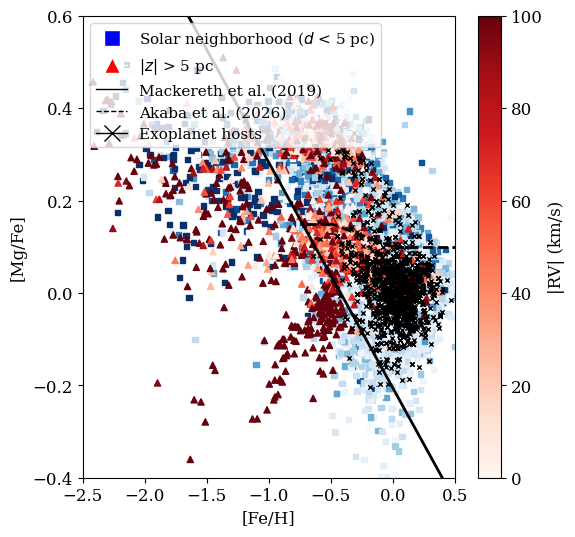

In [61]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
ax.scatter(neighbors['FE_H'], neighbors['MG_FE'], s= 15, c= np.abs(neighbors['GAIAEDR3_DR2_RADIAL_VELOCITY']), cmap = 'Blues', label = r'Solar neighborhood ($d$ < 5 pc)', marker = 's', vmin = 0, vmax=100)
img = ax.scatter(not_neighbors['FE_H'], not_neighbors['MG_FE'], s=20, c = np.abs(not_neighbors['GAIAEDR3_DR2_RADIAL_VELOCITY']), cmap = 'Reds', marker = '^', label = r'$|z|$ > 5 pc', vmin = 0, vmax=100)
ax.scatter(apogee_allstar['FE_H'][exoplanets_apogee_tbl['apogee idx']], apogee_allstar['MG_FE'][exoplanets_apogee_tbl['apogee idx']], color = 'k', alpha = 1, marker = 'x', s =10, label = "Exoplanet hosts")
plt.colorbar(img, label = '|RV| (km/s)', cmap = 'Greys')
ax.set_ylim(-0.4,0.6)
ax.set_xlim(-2.5,0.5)
ax.plot([-1.65, 0.4], [0.6, -0.4], color = 'k', linewidth = 2)
ax.plot([0,0.5],[0.1,0.1], color ='k', linewidth =2, linestyle='--')
ax.plot([0,-0.5],[0.1,0.15], color ='k', linewidth =2, linestyle='--')
ax.plot([-0.5, -0.7],[0.15,0.15], color ='k', linewidth =2, linestyle='--')
props = dict(boxstyle='round', facecolor='white', edgecolor='black')

## turned labels off on plot to get a better view

#ax.text(-2, 0, "ex-situ",fontsize =14, bbox=props)
#ax.text(-0, 0.4, "in-situ",fontsize =14, bbox=props)
#ax.text(-0.3, 0.2, "thick disk",fontsize =14, bbox=props)
#ax.text(-0.1,-0.1, "thin disk",fontsize =14, bbox=props)

legend_elements = [Line2D([0], [0], marker='s', color='w', label=r'Solar neighborhood ($d$ < 5 pc)',
                          markerfacecolor='b', markersize=12), 
                          Line2D([0], [0], marker='^', color='w', label=r'$|z|$ > 5 pc',
                          markerfacecolor='r', markersize=12), 
                          Line2D([0],[0], color = 'k', label = "Mackereth et al. (2019)"), 
                          Line2D([0], [0], linestyle = '--', color = 'k', label = "Akaba et al. (2026)"), 
                          Line2D([0], [0], marker='x', color='k', label=r'Exoplanet hosts',
                          markerfacecolor='k', markersize=12)]
plt.legend(handles =legend_elements, loc = 'upper left', fontsize = 11)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')

We see that the majority of exoplanets reside around hosts in the thin disk! But, we do see a group of them that appear to reside in the thick disk. Now that we know that most of our exoplanets reside in the thin disk, let's check if the exoplanets that appear to fall outside it are truly outside the thin disk or are thick disk migrants into the thin disk. 

Text(0, 0.5, '[Mg/Fe]')

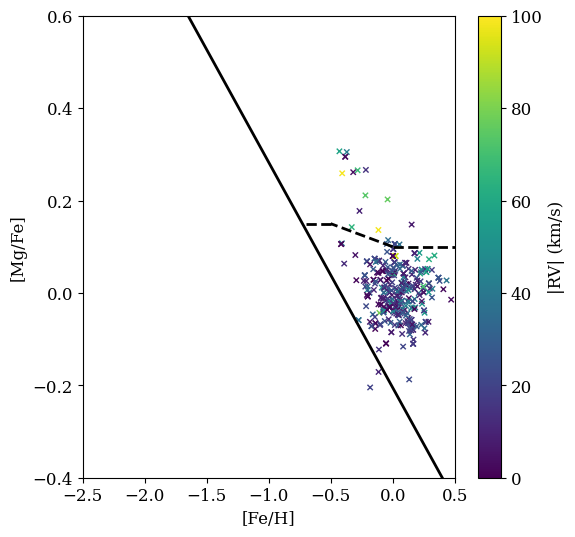

In [63]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
img = ax.scatter(apogee_allstar['FE_H'][exoplanets_apogee_tbl['apogee idx']], apogee_allstar['MG_FE'][exoplanets_apogee_tbl['apogee idx']], c = np.abs(apogee_allstar['GAIAEDR3_DR2_RADIAL_VELOCITY'][exoplanets_apogee_tbl['apogee idx']]), alpha = 1, marker = 'x', s =15, label = "Exoplanet hosts", vmin = 0, vmax=100)
plt.colorbar(img, label = '|RV| (km/s)')
ax.set_ylim(-0.4,0.6)
ax.set_xlim(-2.5,0.5)
ax.plot([-1.65, 0.4], [0.6, -0.4], color = 'k', linewidth = 2)
ax.plot([0,0.5],[0.1,0.1], color ='k', linewidth =2, linestyle='--')
ax.plot([0,-0.5],[0.1,0.15], color ='k', linewidth =2, linestyle='--')
ax.plot([-0.5, -0.7],[0.15,0.15], color ='k', linewidth =2, linestyle='--')
props = dict(boxstyle='round', facecolor='white', edgecolor='black')

## turned labels off on plot to get a better view

#ax.text(-2, 0, "ex-situ",fontsize =14, bbox=props)
#ax.text(-0, 0.4, "in-situ",fontsize =14, bbox=props)
#ax.text(-0.3, 0.2, "thick disk",fontsize =14, bbox=props)
#ax.text(-0.1,-0.1, "thin disk",fontsize =14, bbox=props)

ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')

As we might expect, as a result of observational bias, we don't see any ex-situ exoplanets (although we wouldn't expect too many, even if we could see them...). But, we do identify a couple candidates for exoplanets that potentially survived their star's migration from the thick disk (shown in yellow/teal in the thick disk region). We also spot a few exoplanets that appear to genuinely reside in the thick disk (shown in purple in the thick disk region). 

Now, let's see if we can spot any differences in the planets formed in the thin disk versus the planets formed in the thick disk. We can look at the quantities we calculated earlier (orbital radius and planetary radius)

Text(0, 0.5, '[Mg/Fe]')

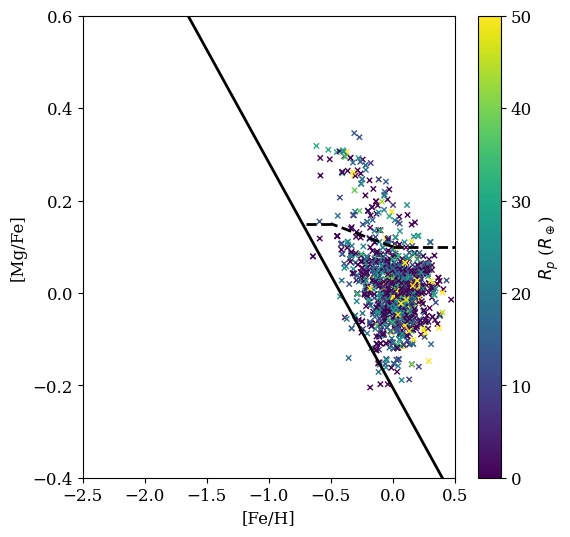

In [64]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
img = ax.scatter(apogee_allstar['FE_H'][exoplanets_apogee_tbl['apogee idx']], apogee_allstar['MG_FE'][exoplanets_apogee_tbl['apogee idx']], c = pl_rad*109, alpha = 1, marker = 'x', s =15, label = "Exoplanet hosts",vmin = 0, vmax = 50)
plt.colorbar(img, label = r'$R_p$ ($R_\oplus$)')
ax.set_ylim(-0.4,0.6)
ax.set_xlim(-2.5,0.5)
ax.plot([-1.65, 0.4], [0.6, -0.4], color = 'k', linewidth = 2)
ax.plot([0,0.5],[0.1,0.1], color ='k', linewidth =2, linestyle='--')
ax.plot([0,-0.5],[0.1,0.15], color ='k', linewidth =2, linestyle='--')
ax.plot([-0.5, -0.7],[0.15,0.15], color ='k', linewidth =2, linestyle='--')
props = dict(boxstyle='round', facecolor='white', edgecolor='black')

## turned labels off on plot to get a better view

#ax.text(-2, 0, "ex-situ",fontsize =14, bbox=props)
#ax.text(-0, 0.4, "in-situ",fontsize =14, bbox=props)
#ax.text(-0.3, 0.2, "thick disk",fontsize =14, bbox=props)
#ax.text(-0.1,-0.1, "thin disk",fontsize =14, bbox=props)

ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')

There we go! Planets with <em>larger</em> radii tend to reside in the thin disk. We can assume that these large radii ($R > 15 R_\oplus$) planets are Jupiter-like gas giant planets. This tells us that gas giants are more likely to form in the thin disk because they "prefer" chemically enriched environments. However, this does not tell us much about rocky worlds--we can really only say that rocky worlds have less preference for chemically enriched environments than their gas giant counterparts.

<b> Jot down some thoughts on why this might be the case: </b>

<b> Answer: </b> 



### To conclude

In this module, we discovered that...
- Most exoplanets orbit around stars that reside on the main sequence. Although this largely because the main sequence is where stars spend the majority of their lives, this is also due to the violent nature of stellar evolution. 
- Exoplanets that form around particularly young stars tend to reside at greater distances from the host star 
- Exoplanets are more easily detected around bright stars when they exhibit larger radii
- The Galactic thin and thick disk populations can be differentiated from one another in metallicitiy space
- However, migration between the disks is possible 
- Gas giants preferentially form in more chemically enriched environments (e.g., the thin disk)